In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
import time
import copy
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

BATCH_SIZE   = 128
EPOCHS_SHORT = 5
EPOCHS_FULL  = 15
LR           = 1e-3
INPUT_SIZE   = 28
SEQ_LEN      = 28

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# MNIST
mnist_train = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
mnist_test  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
mnist_train_loader = DataLoader(mnist_train, batch_size=BATCH_SIZE, shuffle=True)
mnist_test_loader  = DataLoader(mnist_test,  batch_size=BATCH_SIZE, shuffle=False)

# EMNIST-Letters
emnist_train = torchvision.datasets.EMNIST(root='./data', split='letters', train=True,  download=True, transform=transform)
emnist_test  = torchvision.datasets.EMNIST(root='./data', split='letters', train=False, download=True, transform=transform)
emnist_train.targets = emnist_train.targets - 1  # shift labels 1-26 → 0-25
emnist_test.targets  = emnist_test.targets  - 1
emnist_train_loader = DataLoader(emnist_train, batch_size=BATCH_SIZE, shuffle=True)
emnist_test_loader  = DataLoader(emnist_test,  batch_size=BATCH_SIZE, shuffle=False)

NUM_CLASSES_MNIST  = 10
NUM_CLASSES_EMNIST = 26

# ── Utility functions ──────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, clip=None):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.squeeze(1).to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out  = model(X)
        loss = criterion(out, y)
        loss.backward()
        if clip: nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total_loss += loss.item() * X.size(0)
        correct    += (out.argmax(1) == y).sum().item()
        total      += X.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.squeeze(1).to(DEVICE), y.to(DEVICE)
            out  = model(X)
            loss = criterion(out, y)
            total_loss += loss.item() * X.size(0)
            correct    += (out.argmax(1) == y).sum().item()
            total      += X.size(0)
    return total_loss / total, correct / total

def full_train(model, train_loader, test_loader, epochs=EPOCHS_FULL,
               lr=LR, clip=None, label='Model'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history   = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    t0 = time.time()
    for ep in range(1, epochs + 1):
        tl, ta = train_one_epoch(model, train_loader, optimizer, criterion, clip)
        vl, va = evaluate(model, test_loader, criterion)
        history['train_loss'].append(tl); history['train_acc'].append(ta)
        history['val_loss'].append(vl);   history['val_acc'].append(va)
        print(f'[{label}] Ep {ep:02d}/{epochs} | Loss {tl:.4f}/{vl:.4f} | Acc {ta:.3f}/{va:.3f}')
    elapsed = time.time() - t0
    print(f'  → Time: {elapsed:.1f}s | Params: {sum(p.numel() for p in model.parameters()):,}')
    return history, elapsed

def plot_history(histories, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for label, h in histories.items():
        axes[0].plot(h['train_loss'], label=f'{label} train')
        axes[0].plot(h['val_loss'],   label=f'{label} val', linestyle='--')
        axes[1].plot(h['train_acc'],  label=f'{label} train')
        axes[1].plot(h['val_acc'],    label=f'{label} val', linestyle='--')
    for ax, t in zip(axes, ['Loss', 'Accuracy']):
        ax.set_title(f'{title} — {t}'); ax.legend(fontsize=7); ax.grid(True)
    plt.tight_layout(); plt.show()

def plot_confusion(model, loader, classes, title='Confusion Matrix'):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in loader:
            preds = model(X.squeeze(1).to(DEVICE)).argmax(1).cpu().numpy()
            all_preds.extend(preds); all_labels.extend(y.numpy())
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(max(8, len(classes)//2), max(6, len(classes)//2)))
    sns.heatmap(cm, annot=len(classes) <= 20, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.tight_layout(); plt.show()
    print(classification_report(all_labels, all_preds, target_names=[str(c) for c in classes]))

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def measure_inference_time(model, loader, n_batches=20):
    model.eval()
    times = []
    with torch.no_grad():
        for i, (X, _) in enumerate(loader):
            if i >= n_batches: break
            X = X.squeeze(1).to(DEVICE)
            t0 = time.time(); model(X); times.append(time.time() - t0)
    return np.mean(times) * 1000  # ms



Using device: mps


─── Scratch RNN on MNIST ───
[RNN-Scratch] Ep 01/5 | Loss 0.8961/0.4621 | Acc 0.690/0.861
[RNN-Scratch] Ep 02/5 | Loss 0.3990/0.2759 | Acc 0.879/0.920
[RNN-Scratch] Ep 03/5 | Loss 0.2801/0.2481 | Acc 0.921/0.927
[RNN-Scratch] Ep 04/5 | Loss 0.2288/0.1947 | Acc 0.937/0.945
[RNN-Scratch] Ep 05/5 | Loss 0.1970/0.1706 | Acc 0.945/0.951
  → Time: 54.0s | Params: 21,386

─── PyTorch RNN: 1 / 2 / 3 layers ───
[RNN-1L] Ep 01/5 | Loss 0.8645/0.4196 | Acc 0.714/0.876
[RNN-1L] Ep 02/5 | Loss 0.3721/0.3500 | Acc 0.893/0.901
[RNN-1L] Ep 03/5 | Loss 0.2623/0.2079 | Acc 0.927/0.942
[RNN-1L] Ep 04/5 | Loss 0.2091/0.1779 | Acc 0.942/0.951
[RNN-1L] Ep 05/5 | Loss 0.1767/0.1851 | Acc 0.950/0.949
  → Time: 47.8s | Params: 21,514
[RNN-2L] Ep 01/5 | Loss 0.7496/0.3602 | Acc 0.748/0.894
[RNN-2L] Ep 02/5 | Loss 0.3001/0.2387 | Acc 0.912/0.926
[RNN-2L] Ep 03/5 | Loss 0.2210/0.1721 | Acc 0.936/0.950
[RNN-2L] Ep 04/5 | Loss 0.1748/0.1504 | Acc 0.950/0.956
[RNN-2L] Ep 05/5 | Loss 0.1509/0.1581 | Acc 0.956/0.955
 

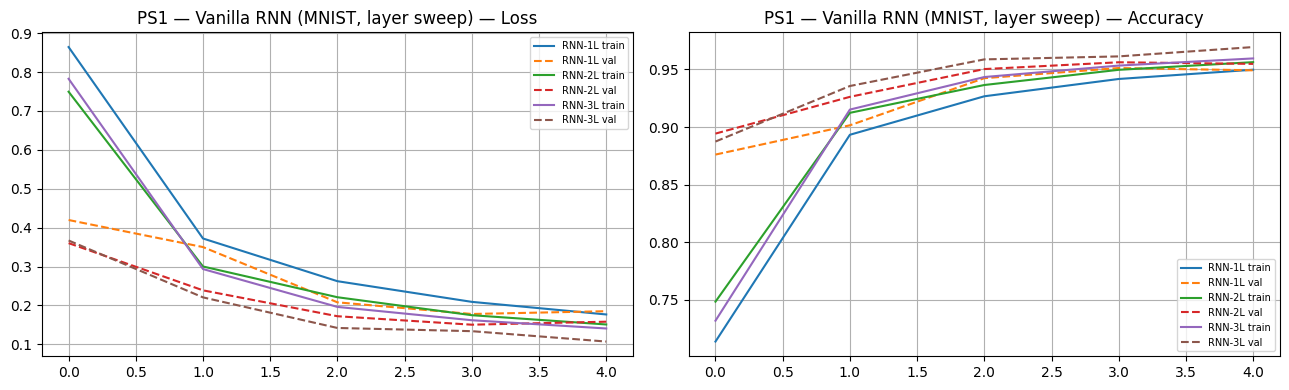


─── Row vs Column scanning ───
[Row-wise] Ep 01/5 | Loss 0.8621/0.4779 | Acc 0.719/0.849
[Row-wise] Ep 02/5 | Loss 0.3662/0.3588 | Acc 0.893/0.892
[Row-wise] Ep 03/5 | Loss 0.2628/0.2377 | Acc 0.924/0.933
[Row-wise] Ep 04/5 | Loss 0.2216/0.2018 | Acc 0.937/0.944
[Row-wise] Ep 05/5 | Loss 0.1874/0.2196 | Acc 0.947/0.936
  → Time: 47.5s | Params: 21,514
[Col-wise] Ep 01/5 | Loss 1.1296/0.6011 | Acc 0.618/0.822
[Col-wise] Ep 02/5 | Loss 0.4819/0.3573 | Acc 0.857/0.899
[Col-wise] Ep 03/5 | Loss 0.3295/0.2711 | Acc 0.906/0.922
[Col-wise] Ep 04/5 | Loss 0.2720/0.2271 | Acc 0.923/0.936
[Col-wise] Ep 05/5 | Loss 0.2332/0.1854 | Acc 0.933/0.946
  → Time: 48.0s | Params: 21,514


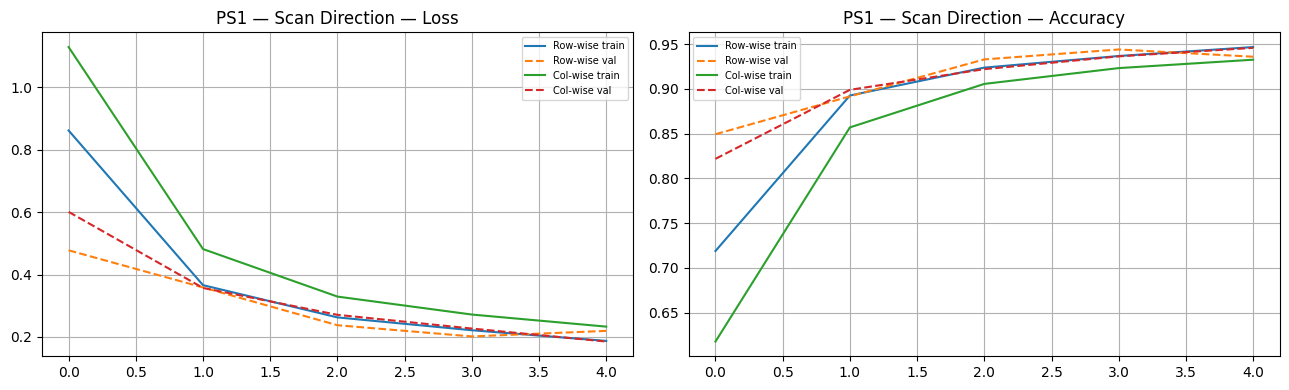


─── Vanishing Gradient Analysis ───


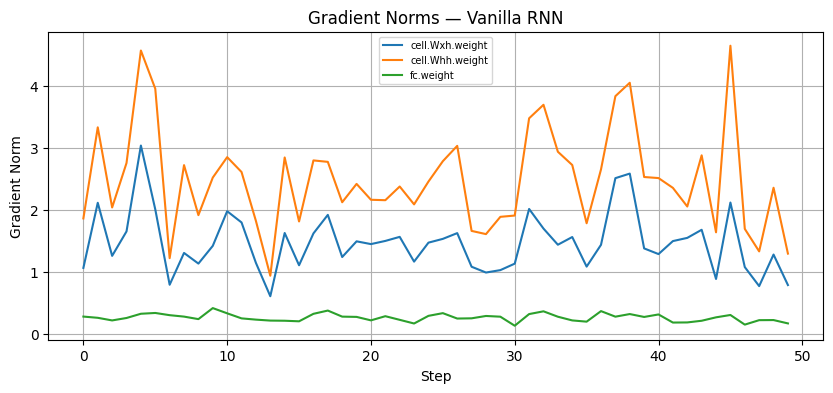


─── Vanilla RNN on EMNIST-Letters ───
[RNN-EMNIST] Ep 01/5 | Loss 1.7648/1.1113 | Acc 0.467/0.676
[RNN-EMNIST] Ep 02/5 | Loss 0.9852/0.9063 | Acc 0.707/0.735
[RNN-EMNIST] Ep 03/5 | Loss 0.7918/0.7760 | Acc 0.765/0.770
[RNN-EMNIST] Ep 04/5 | Loss 0.7012/0.6811 | Acc 0.791/0.799
[RNN-EMNIST] Ep 05/5 | Loss 0.6410/0.6227 | Acc 0.808/0.819
  → Time: 100.9s | Params: 23,578


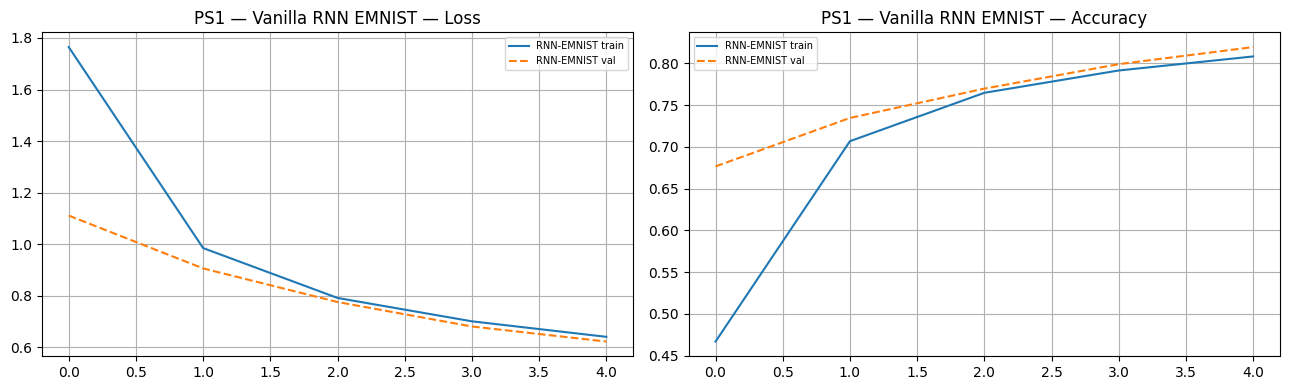

In [2]:
# ═══════════════════════════════════════════════════════════════
# PS1 — Vanilla RNN
# ═══════════════════════════════════════════════════════════════

# ── RNN from scratch ──
class VanillaRNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.Wxh  = nn.Linear(input_size,  hidden_size, bias=False)
        self.Whh  = nn.Linear(hidden_size, hidden_size, bias=True)
        self.tanh = nn.Tanh()
    def forward(self, x, h):
        return self.tanh(self.Wxh(x) + self.Whh(h))

class VanillaRNNScratch(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = VanillaRNNCell(input_size, hidden_size)
        self.fc   = nn.Linear(hidden_size, num_classes)
    def forward(self, x):        # x: (B,28,28)
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden_size, device=x.device)
        for t in range(T):
            h = self.cell(x[:, t, :], h)
        return self.fc(h)

# ── PyTorch nn.RNN (stackable) ──
class VanillaRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=num_layers,
                          batch_first=True,
                          dropout=0.2 if num_layers > 1 else 0.0)
        self.fc  = nn.Linear(hidden_size, num_classes)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

# ── Column-wise scan ──
class VanillaRNNColWise(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc  = nn.Linear(hidden_size, num_classes)
    def forward(self, x):
        x = x.permute(0, 2, 1)   # (B,28cols,28rows)
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

# ── Gradient norm tracker ──
def record_gradient_norms(model, loader, steps=50):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    grad_norms = {n: [] for n, _ in model.named_parameters() if 'weight' in n}
    model.train()
    for i, (X, y) in enumerate(loader):
        if i >= steps: break
        X, y = X.squeeze(1).to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        criterion(model(X), y).backward()
        for n, p in model.named_parameters():
            if 'weight' in n and p.grad is not None:
                grad_norms[n].append(p.grad.norm().item())
        optimizer.step()
    return grad_norms

# ── Run PS1 ───────────────────────────────────────────────────
print('─── Scratch RNN on MNIST ───')
rnn_scratch = VanillaRNNScratch(INPUT_SIZE, 128, NUM_CLASSES_MNIST).to(DEVICE)
h_scratch, _ = full_train(rnn_scratch, mnist_train_loader, mnist_test_loader,
                           epochs=EPOCHS_SHORT, label='RNN-Scratch')

print('\n─── PyTorch RNN: 1 / 2 / 3 layers ───')
rnn_layer_results = {}
for nl in [1, 2, 3]:
    m = VanillaRNN(INPUT_SIZE, 128, nl, NUM_CLASSES_MNIST).to(DEVICE)
    h, _ = full_train(m, mnist_train_loader, mnist_test_loader,
                      epochs=EPOCHS_SHORT, label=f'RNN-{nl}L')
    rnn_layer_results[f'RNN-{nl}L'] = h
plot_history(rnn_layer_results, 'PS1 — Vanilla RNN (MNIST, layer sweep)')

print('\n─── Row vs Column scanning ───')
rnn_row = VanillaRNN(INPUT_SIZE, 128, 1, NUM_CLASSES_MNIST).to(DEVICE)
rnn_col = VanillaRNNColWise(INPUT_SIZE, 128, NUM_CLASSES_MNIST).to(DEVICE)
h_row, _ = full_train(rnn_row, mnist_train_loader, mnist_test_loader, epochs=EPOCHS_SHORT, label='Row-wise')
h_col, _ = full_train(rnn_col, mnist_train_loader, mnist_test_loader, epochs=EPOCHS_SHORT, label='Col-wise')
plot_history({'Row-wise': h_row, 'Col-wise': h_col}, 'PS1 — Scan Direction')

print('\n─── Vanishing Gradient Analysis ───')
grad_norms = record_gradient_norms(rnn_scratch, mnist_train_loader)
plt.figure(figsize=(10, 4))
for layer, norms in grad_norms.items():
    plt.plot(norms, label=layer)
plt.title('Gradient Norms — Vanilla RNN'); plt.xlabel('Step')
plt.ylabel('Gradient Norm'); plt.legend(fontsize=7); plt.grid(True); plt.show()

print('\n─── Vanilla RNN on EMNIST-Letters ───')
rnn_emnist = VanillaRNN(INPUT_SIZE, 128, 1, NUM_CLASSES_EMNIST).to(DEVICE)
h_re, _ = full_train(rnn_emnist, emnist_train_loader, emnist_test_loader,
                     epochs=EPOCHS_SHORT, label='RNN-EMNIST')
plot_history({'RNN-EMNIST': h_re}, 'PS1 — Vanilla RNN EMNIST')



─── LSTM hidden-unit sweep on MNIST ───
[LSTM-H32] Ep 01/5 | Loss 1.0503/0.3868 | Acc 0.660/0.891
[LSTM-H32] Ep 02/5 | Loss 0.3024/0.2211 | Acc 0.914/0.939
[LSTM-H32] Ep 03/5 | Loss 0.1952/0.1717 | Acc 0.944/0.951
[LSTM-H32] Ep 04/5 | Loss 0.1523/0.1460 | Acc 0.956/0.956
[LSTM-H32] Ep 05/5 | Loss 0.1305/0.1206 | Acc 0.962/0.965
  → Time: 38.3s | Params: 8,266
[LSTM-H64] Ep 01/5 | Loss 0.7325/0.2254 | Acc 0.765/0.937
[LSTM-H64] Ep 02/5 | Loss 0.1890/0.1401 | Acc 0.947/0.959
[LSTM-H64] Ep 03/5 | Loss 0.1315/0.1156 | Acc 0.962/0.965
[LSTM-H64] Ep 04/5 | Loss 0.1086/0.0923 | Acc 0.968/0.972
[LSTM-H64] Ep 05/5 | Loss 0.0857/0.0812 | Acc 0.976/0.977
  → Time: 39.1s | Params: 24,714
[LSTM-H128] Ep 01/5 | Loss 0.5602/0.1987 | Acc 0.815/0.941
[LSTM-H128] Ep 02/5 | Loss 0.1424/0.1192 | Acc 0.957/0.965
[LSTM-H128] Ep 03/5 | Loss 0.0980/0.1127 | Acc 0.971/0.965
[LSTM-H128] Ep 04/5 | Loss 0.0749/0.0760 | Acc 0.978/0.977
[LSTM-H128] Ep 05/5 | Loss 0.0605/0.0646 | Acc 0.982/0.980
  → Time: 45.7s | Pa

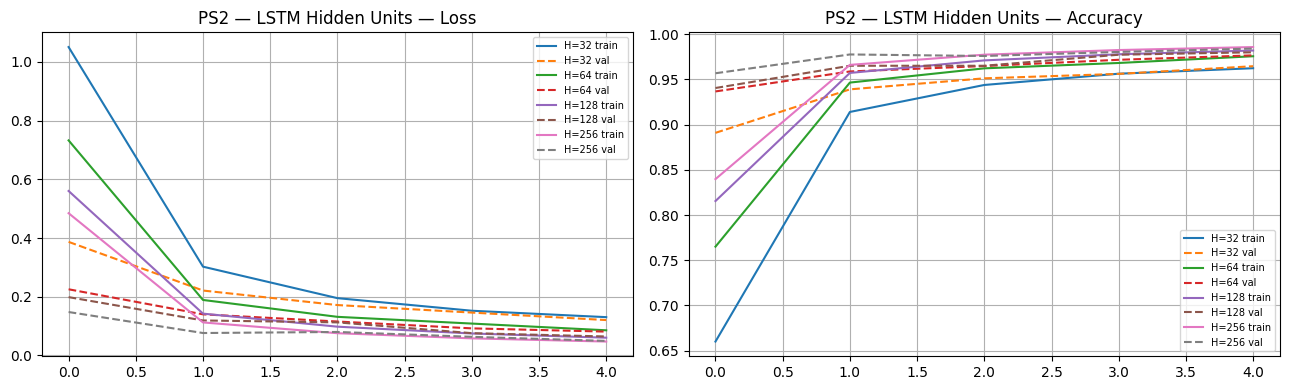


─── LSTM dropout analysis ───
[drop=0.0] Ep 01/5 | Loss 0.4814/0.1700 | Acc 0.840/0.947
[drop=0.0] Ep 02/5 | Loss 0.1144/0.0746 | Acc 0.966/0.977
[drop=0.0] Ep 03/5 | Loss 0.0773/0.0594 | Acc 0.976/0.981
[drop=0.0] Ep 04/5 | Loss 0.0562/0.0475 | Acc 0.983/0.985
[drop=0.0] Ep 05/5 | Loss 0.0485/0.0554 | Acc 0.985/0.984
  → Time: 56.2s | Params: 214,282
[drop=0.2] Ep 01/5 | Loss 0.4280/0.1258 | Acc 0.860/0.961
[drop=0.2] Ep 02/5 | Loss 0.1061/0.0816 | Acc 0.968/0.975
[drop=0.2] Ep 03/5 | Loss 0.0758/0.0677 | Acc 0.978/0.980
[drop=0.2] Ep 04/5 | Loss 0.0600/0.0593 | Acc 0.982/0.983
[drop=0.2] Ep 05/5 | Loss 0.0469/0.0512 | Acc 0.986/0.983
  → Time: 53.0s | Params: 214,282
[drop=0.3] Ep 01/5 | Loss 0.4817/0.1381 | Acc 0.844/0.956
[drop=0.3] Ep 02/5 | Loss 0.1250/0.0831 | Acc 0.963/0.975
[drop=0.3] Ep 03/5 | Loss 0.0856/0.0717 | Acc 0.975/0.978
[drop=0.3] Ep 04/5 | Loss 0.0646/0.0581 | Acc 0.981/0.983
[drop=0.3] Ep 05/5 | Loss 0.0520/0.0470 | Acc 0.984/0.985
  → Time: 55.1s | Params: 214,2

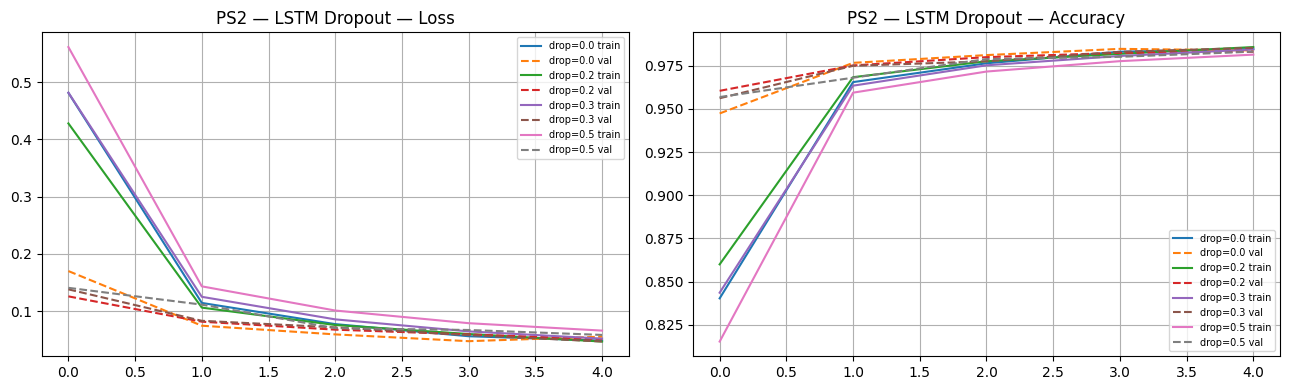


─── Gate visualization ───


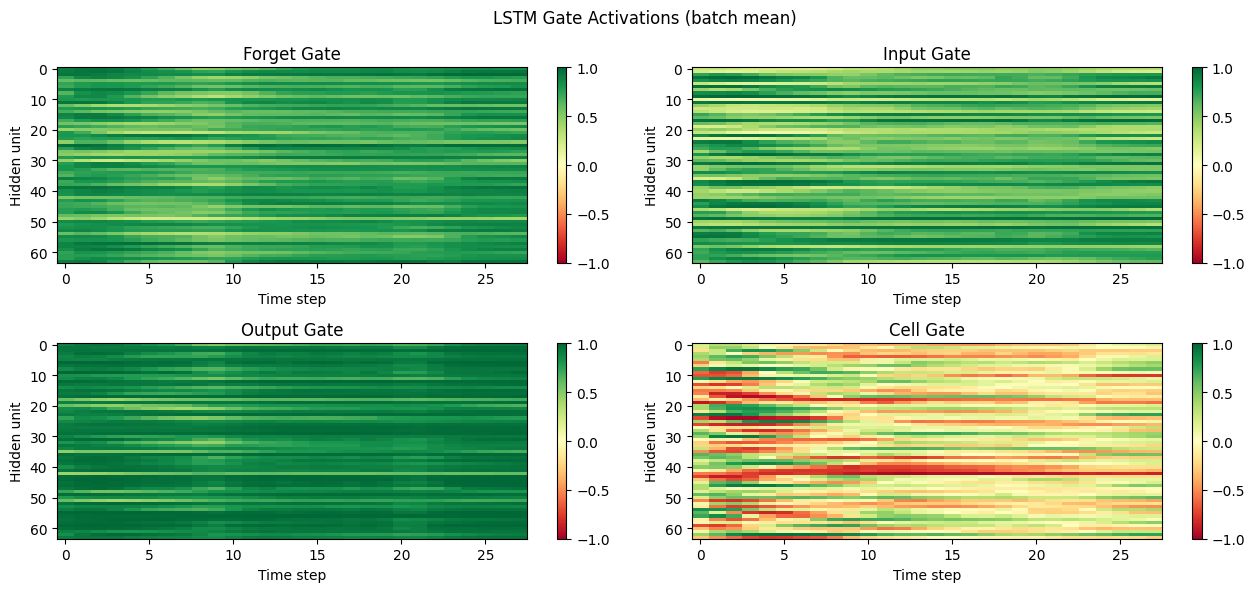


─── LSTM on EMNIST-Letters ───
[LSTM-EMNIST] Ep 01/5 | Loss 0.8513/0.3792 | Acc 0.746/0.881
[LSTM-EMNIST] Ep 02/5 | Loss 0.3610/0.3002 | Acc 0.887/0.904
[LSTM-EMNIST] Ep 03/5 | Loss 0.2893/0.2692 | Acc 0.908/0.915
[LSTM-EMNIST] Ep 04/5 | Loss 0.2577/0.2612 | Acc 0.917/0.915
[LSTM-EMNIST] Ep 05/5 | Loss 0.2305/0.2465 | Acc 0.924/0.921
  → Time: 114.1s | Params: 216,346


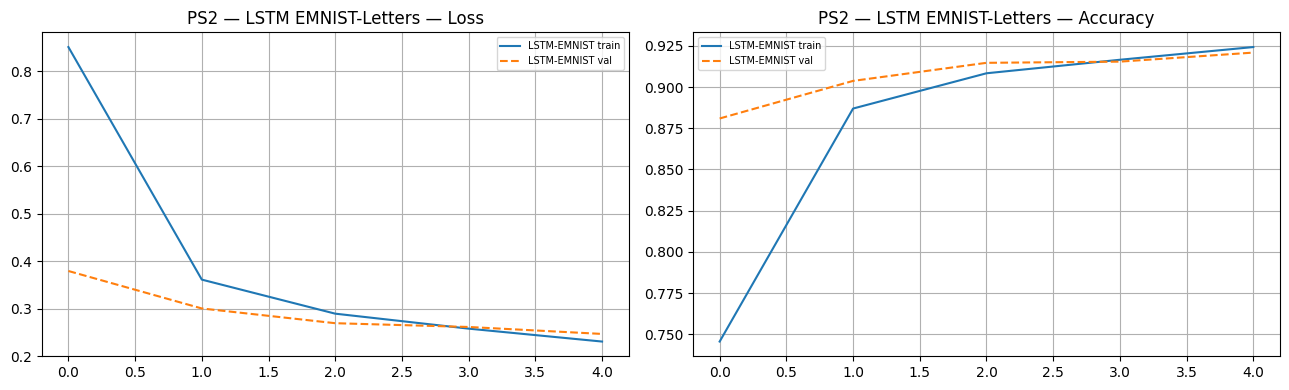

In [3]:
# ═══════════════════════════════════════════════════════════════
# PS2 — LSTM
# ═══════════════════════════════════════════════════════════════

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size, num_classes)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.drop(out[:, -1, :]))

# ── Manual LSTM cell to expose gate activations ──
class LSTMWithGates(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell        = nn.LSTMCell(input_size, hidden_size)
        self.fc          = nn.Linear(hidden_size, num_classes)
        self.gate_log    = {}

    def forward(self, x, log_gates=False):
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden_size, device=x.device)
        c = torch.zeros(B, self.hidden_size, device=x.device)
        if log_gates:
            self.gate_log = {'Forget': [], 'Input': [], 'Output': [], 'Cell': []}
        for t in range(T):
            raw = (x[:, t, :] @ self.cell.weight_ih.T +
                   h            @ self.cell.weight_hh.T +
                   self.cell.bias_ih + self.cell.bias_hh)
            H  = self.hidden_size
            f  = torch.sigmoid(raw[:, :H])
            i  = torch.sigmoid(raw[:, H:2*H])
            g  = torch.tanh   (raw[:, 2*H:3*H])
            o  = torch.sigmoid(raw[:, 3*H:])
            c  = f * c + i * g
            h  = o * torch.tanh(c)
            if log_gates:
                self.gate_log['Forget'].append(f.detach().mean(0).cpu().numpy())
                self.gate_log['Input'].append(i.detach().mean(0).cpu().numpy())
                self.gate_log['Output'].append(o.detach().mean(0).cpu().numpy())
                self.gate_log['Cell'].append(g.detach().mean(0).cpu().numpy())
        return self.fc(h)

def plot_gate_activations(model, loader):
    model.eval()
    X, _ = next(iter(loader))
    model(X.squeeze(1)[:8].to(DEVICE), log_gates=True)
    fig, axes = plt.subplots(2, 2, figsize=(13, 6))
    for ax, (gate, vals) in zip(axes.flatten(), model.gate_log.items()):
        mat = np.array(vals)   # (T, H)
        im  = ax.imshow(mat.T, aspect='auto', cmap='RdYlGn', vmin=-1, vmax=1)
        ax.set_title(f'{gate} Gate'); ax.set_xlabel('Time step'); ax.set_ylabel('Hidden unit')
        plt.colorbar(im, ax=ax)
    plt.suptitle('LSTM Gate Activations (batch mean)')
    plt.tight_layout(); plt.show()

# ── Run PS2 ───────────────────────────────────────────────────
print('─── LSTM hidden-unit sweep on MNIST ───')
lstm_hu_results = {}
for hu in [32, 64, 128, 256]:
    m = LSTMModel(INPUT_SIZE, hu, 1, NUM_CLASSES_MNIST).to(DEVICE)
    h, _ = full_train(m, mnist_train_loader, mnist_test_loader,
                      epochs=EPOCHS_SHORT, label=f'LSTM-H{hu}')
    lstm_hu_results[f'H={hu}'] = h
plot_history(lstm_hu_results, 'PS2 — LSTM Hidden Units')

print('\n─── LSTM dropout analysis ───')
drop_results = {}
for dr in [0.0, 0.2, 0.3, 0.5]:
    m = LSTMModel(INPUT_SIZE, 128, 2, NUM_CLASSES_MNIST, dropout=dr).to(DEVICE)
    h, _ = full_train(m, mnist_train_loader, mnist_test_loader,
                      epochs=EPOCHS_SHORT, label=f'drop={dr}')
    drop_results[f'drop={dr}'] = h
plot_history(drop_results, 'PS2 — LSTM Dropout')

print('\n─── Gate visualization ───')
gate_model = LSTMWithGates(INPUT_SIZE, 64, NUM_CLASSES_MNIST).to(DEVICE)
opt_g  = optim.Adam(gate_model.parameters(), lr=LR)
crit_g = nn.CrossEntropyLoss()
for ep in range(3):
    for X, y in mnist_train_loader:
        X, y = X.squeeze(1).to(DEVICE), y.to(DEVICE)
        opt_g.zero_grad(); crit_g(gate_model(X), y).backward(); opt_g.step()
plot_gate_activations(gate_model, mnist_test_loader)

print('\n─── LSTM on EMNIST-Letters ───')
lstm_emnist = LSTMModel(INPUT_SIZE, 128, 2, NUM_CLASSES_EMNIST, dropout=0.3).to(DEVICE)
h_le, _ = full_train(lstm_emnist, emnist_train_loader, emnist_test_loader,
                     epochs=EPOCHS_SHORT, label='LSTM-EMNIST')
plot_history({'LSTM-EMNIST': h_le}, 'PS2 — LSTM EMNIST-Letters')



─── GRU stacked layers on MNIST ───
[GRU-1L] Ep 01/5 | Loss 0.6267/0.2228 | Acc 0.795/0.931
[GRU-1L] Ep 02/5 | Loss 0.1464/0.1066 | Acc 0.956/0.969
[GRU-1L] Ep 03/5 | Loss 0.0944/0.0881 | Acc 0.972/0.973
[GRU-1L] Ep 04/5 | Loss 0.0712/0.0697 | Acc 0.979/0.979
[GRU-1L] Ep 05/5 | Loss 0.0583/0.0586 | Acc 0.982/0.982
  → Time: 64.5s | Params: 61,962
[GRU-2L] Ep 01/5 | Loss 0.4987/0.1118 | Acc 0.834/0.967
[GRU-2L] Ep 02/5 | Loss 0.0980/0.0609 | Acc 0.971/0.982
[GRU-2L] Ep 03/5 | Loss 0.0618/0.0511 | Acc 0.981/0.986
[GRU-2L] Ep 04/5 | Loss 0.0463/0.0453 | Acc 0.986/0.986
[GRU-2L] Ep 05/5 | Loss 0.0382/0.0531 | Acc 0.989/0.983
  → Time: 92.6s | Params: 161,034
[GRU-3L] Ep 01/5 | Loss 0.4110/0.1040 | Acc 0.866/0.969
[GRU-3L] Ep 02/5 | Loss 0.0883/0.0564 | Acc 0.973/0.982
[GRU-3L] Ep 03/5 | Loss 0.0586/0.0560 | Acc 0.983/0.983
[GRU-3L] Ep 04/5 | Loss 0.0430/0.0495 | Acc 0.987/0.986
[GRU-3L] Ep 05/5 | Loss 0.0355/0.0399 | Acc 0.989/0.988
  → Time: 125.2s | Params: 260,106


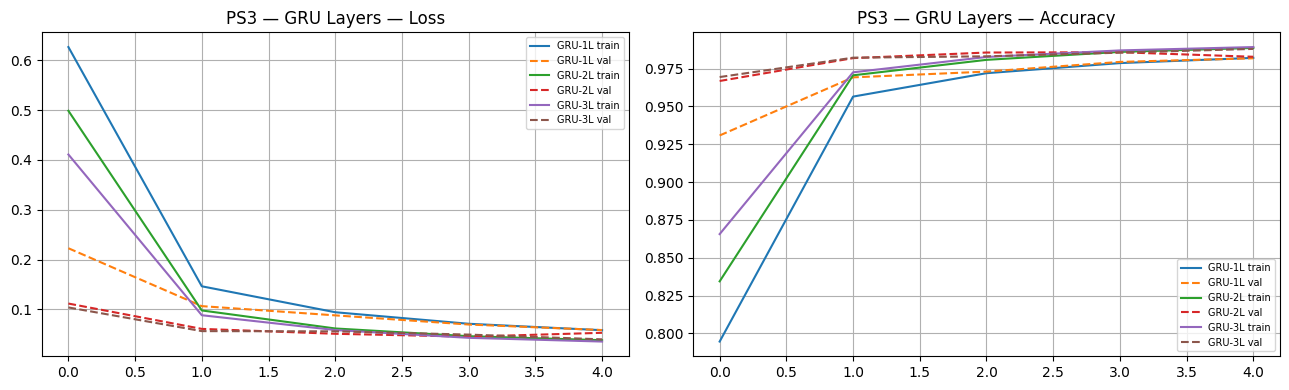


─── GRU vs LSTM: accuracy / time / params ───
[GRU-1L] Ep 01/5 | Loss 0.6419/0.1807 | Acc 0.793/0.950
[GRU-1L] Ep 02/5 | Loss 0.1538/0.1158 | Acc 0.955/0.967
[GRU-1L] Ep 03/5 | Loss 0.1015/0.0888 | Acc 0.970/0.974
[GRU-1L] Ep 04/5 | Loss 0.0759/0.0735 | Acc 0.977/0.978
[GRU-1L] Ep 05/5 | Loss 0.0616/0.0609 | Acc 0.981/0.981
  → Time: 63.5s | Params: 61,962
[GRU-2L] Ep 01/5 | Loss 0.4712/0.1189 | Acc 0.843/0.966
[GRU-2L] Ep 02/5 | Loss 0.1012/0.0681 | Acc 0.969/0.980
[GRU-2L] Ep 03/5 | Loss 0.0636/0.0651 | Acc 0.981/0.981
[GRU-2L] Ep 04/5 | Loss 0.0493/0.0507 | Acc 0.984/0.985
[GRU-2L] Ep 05/5 | Loss 0.0397/0.0457 | Acc 0.987/0.986
  → Time: 92.4s | Params: 161,034
[LSTM-1L] Ep 01/5 | Loss 0.5432/0.1871 | Acc 0.823/0.942
[LSTM-1L] Ep 02/5 | Loss 0.1319/0.1000 | Acc 0.961/0.971
[LSTM-1L] Ep 03/5 | Loss 0.0908/0.0858 | Acc 0.973/0.975
[LSTM-1L] Ep 04/5 | Loss 0.0718/0.0690 | Acc 0.979/0.979
[LSTM-1L] Ep 05/5 | Loss 0.0569/0.0655 | Acc 0.983/0.981
  → Time: 46.1s | Params: 82,186
[LSTM-2L

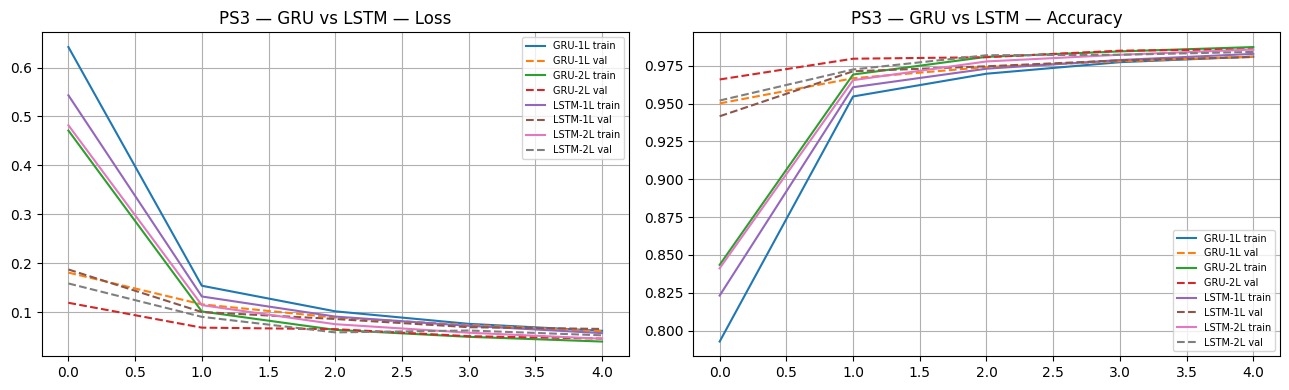


Model            Params    Infer(ms)   TrainTime(s)   ValAcc
──────────────────────────────────────────────────────────────
GRU-1L           61,962         2.84           63.5    0.981
GRU-2L          161,034         5.58           92.4    0.986
LSTM-1L          82,186         0.57           46.1    0.981
LSTM-2L         214,282         1.06           54.9    0.984

─── GRU on EMNIST-Letters ───
[GRU-EMNIST] Ep 01/5 | Loss 0.9537/0.3822 | Acc 0.710/0.879
[GRU-EMNIST] Ep 02/5 | Loss 0.3504/0.2998 | Acc 0.889/0.905
[GRU-EMNIST] Ep 03/5 | Loss 0.2778/0.2766 | Acc 0.910/0.912
[GRU-EMNIST] Ep 04/5 | Loss 0.2400/0.2352 | Acc 0.921/0.925
[GRU-EMNIST] Ep 05/5 | Loss 0.2183/0.2257 | Acc 0.927/0.927
  → Time: 194.4s | Params: 163,098


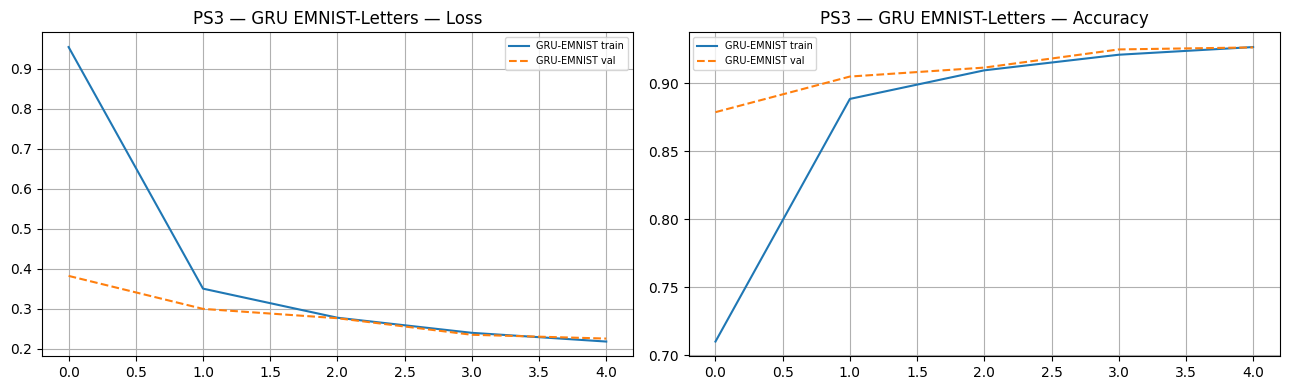

In [4]:
# ═══════════════════════════════════════════════════════════════
# PS3 — GRU
# ═══════════════════════════════════════════════════════════════

class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.0):
        super().__init__()
        self.gru  = nn.GRU(input_size, hidden_size, num_layers=num_layers,
                           batch_first=True,
                           dropout=dropout if num_layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size, num_classes)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(self.drop(out[:, -1, :]))

# ── Run PS3 ───────────────────────────────────────────────────
print('─── GRU stacked layers on MNIST ───')
gru_layer_results = {}
for nl in [1, 2, 3]:
    m = GRUModel(INPUT_SIZE, 128, nl, NUM_CLASSES_MNIST).to(DEVICE)
    h, _ = full_train(m, mnist_train_loader, mnist_test_loader,
                      epochs=EPOCHS_SHORT, label=f'GRU-{nl}L')
    gru_layer_results[f'GRU-{nl}L'] = h
plot_history(gru_layer_results, 'PS3 — GRU Layers')

print('\n─── GRU vs LSTM: accuracy / time / params ───')
comparison = {}
summary    = {}

for name, model in [
    ('GRU-1L',  GRUModel(INPUT_SIZE, 128, 1, NUM_CLASSES_MNIST)),
    ('GRU-2L',  GRUModel(INPUT_SIZE, 128, 2, NUM_CLASSES_MNIST)),
    ('LSTM-1L', LSTMModel(INPUT_SIZE, 128, 1, NUM_CLASSES_MNIST)),
    ('LSTM-2L', LSTMModel(INPUT_SIZE, 128, 2, NUM_CLASSES_MNIST)),
]:
    model = model.to(DEVICE)
    h, t  = full_train(model, mnist_train_loader, mnist_test_loader,
                       epochs=EPOCHS_SHORT, label=name)
    comparison[name] = h
    summary[name] = {
        'params':     count_params(model),
        'infer_ms':   measure_inference_time(model, mnist_test_loader),
        'val_acc':    h['val_acc'][-1],
        'train_sec':  t,
    }

plot_history(comparison, 'PS3 — GRU vs LSTM')

print(f'\n{"Model":<12} {"Params":>10} {"Infer(ms)":>12} {"TrainTime(s)":>14} {"ValAcc":>8}')
print('─' * 62)
for name, s in summary.items():
    print(f'{name:<12} {s["params"]:>10,} {s["infer_ms"]:>12.2f} {s["train_sec"]:>14.1f} {s["val_acc"]:>8.3f}')

print('\n─── GRU on EMNIST-Letters ───')
gru_emnist = GRUModel(INPUT_SIZE, 128, 2, NUM_CLASSES_EMNIST, dropout=0.3).to(DEVICE)
h_ge, _ = full_train(gru_emnist, emnist_train_loader, emnist_test_loader,
                     epochs=EPOCHS_SHORT, label='GRU-EMNIST')
plot_history({'GRU-EMNIST': h_ge}, 'PS3 — GRU EMNIST-Letters')



─── BiLSTM concat vs average on MNIST ───
[BiLSTM-concat] Ep 01/5 | Loss 0.4996/0.1505 | Acc 0.838/0.953
[BiLSTM-concat] Ep 02/5 | Loss 0.1188/0.0970 | Acc 0.964/0.971
[BiLSTM-concat] Ep 03/5 | Loss 0.0797/0.0764 | Acc 0.976/0.977
[BiLSTM-concat] Ep 04/5 | Loss 0.0583/0.0618 | Acc 0.982/0.981
[BiLSTM-concat] Ep 05/5 | Loss 0.0513/0.0545 | Acc 0.984/0.982
  → Time: 58.0s | Params: 164,362
[BiLSTM-avg] Ep 01/5 | Loss 0.5128/0.1387 | Acc 0.840/0.961
[BiLSTM-avg] Ep 02/5 | Loss 0.1127/0.0985 | Acc 0.967/0.971
[BiLSTM-avg] Ep 03/5 | Loss 0.0761/0.0847 | Acc 0.977/0.974
[BiLSTM-avg] Ep 04/5 | Loss 0.0619/0.0696 | Acc 0.981/0.978
[BiLSTM-avg] Ep 05/5 | Loss 0.0497/0.0581 | Acc 0.985/0.984
  → Time: 56.1s | Params: 163,082

─── Unidirectional LSTM vs BiLSTM ───
[Uni-LSTM] Ep 01/5 | Loss 0.5330/0.1850 | Acc 0.829/0.944
[Uni-LSTM] Ep 02/5 | Loss 0.1343/0.1009 | Acc 0.961/0.970
[Uni-LSTM] Ep 03/5 | Loss 0.0889/0.0755 | Acc 0.973/0.977
[Uni-LSTM] Ep 04/5 | Loss 0.0713/0.0669 | Acc 0.979/0.980
[Uni

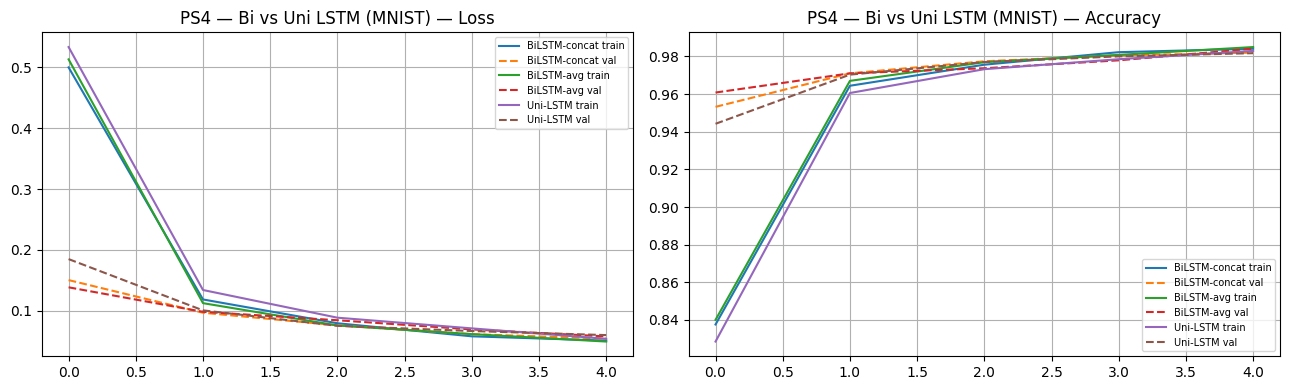


─── BiGRU on MNIST ───
[BiGRU] Ep 01/5 | Loss 0.5327/0.1218 | Acc 0.824/0.964
[BiGRU] Ep 02/5 | Loss 0.1073/0.0756 | Acc 0.968/0.978
[BiGRU] Ep 03/5 | Loss 0.0717/0.0660 | Acc 0.978/0.979
[BiGRU] Ep 04/5 | Loss 0.0544/0.0521 | Acc 0.983/0.984
[BiGRU] Ep 05/5 | Loss 0.0434/0.0490 | Acc 0.987/0.984
  → Time: 90.8s | Params: 123,914


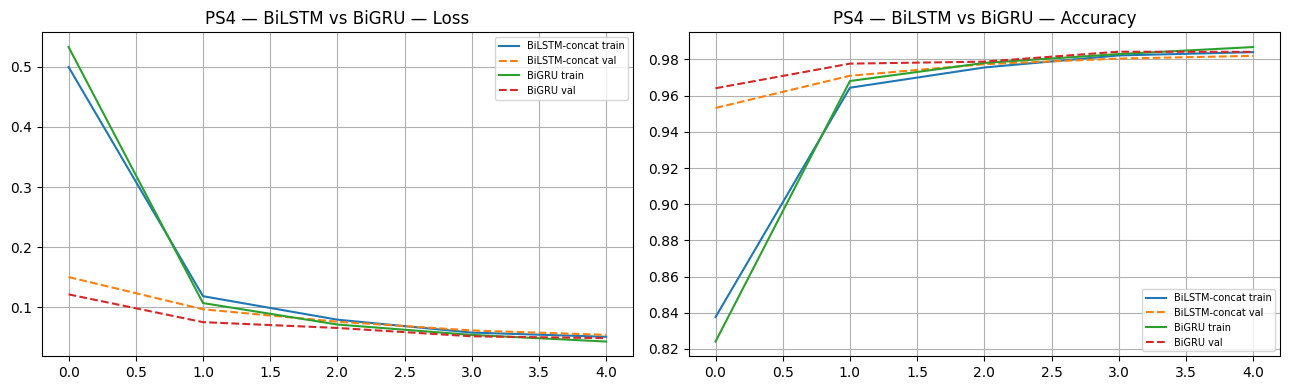


─── BiLSTM on EMNIST-Letters ───
[BiLSTM-EMNIST] Ep 01/5 | Loss 0.8026/0.3652 | Acc 0.759/0.887
[BiLSTM-EMNIST] Ep 02/5 | Loss 0.3405/0.2892 | Acc 0.891/0.910
[BiLSTM-EMNIST] Ep 03/5 | Loss 0.2714/0.2563 | Acc 0.912/0.919
[BiLSTM-EMNIST] Ep 04/5 | Loss 0.2386/0.2496 | Acc 0.921/0.919
[BiLSTM-EMNIST] Ep 05/5 | Loss 0.2170/0.2333 | Acc 0.927/0.924
  → Time: 116.8s | Params: 168,474


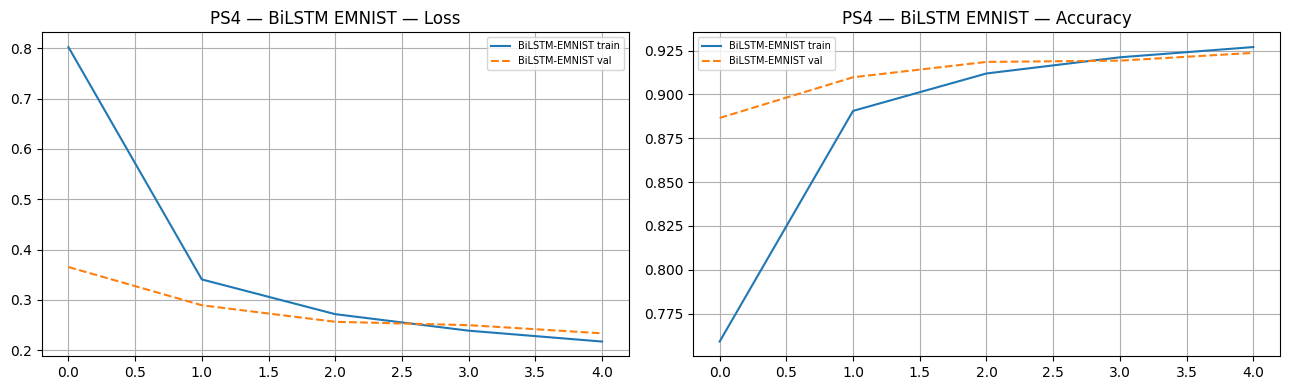

In [5]:
# ═══════════════════════════════════════════════════════════════
# PS4 — Bidirectional LSTM & GRU
# ═══════════════════════════════════════════════════════════════

class BiRNN(nn.Module):
    """Bidirectional LSTM or GRU with concat or average merge."""
    def __init__(self, input_size, hidden_size, num_classes,
                 rnn_type='lstm', merge='concat', num_layers=1, dropout=0.0):
        super().__init__()
        self.merge   = merge
        RNNCls       = nn.LSTM if rnn_type == 'lstm' else nn.GRU
        self.rnn     = RNNCls(input_size, hidden_size,
                               num_layers=num_layers, batch_first=True,
                               bidirectional=True,
                               dropout=dropout if num_layers > 1 else 0.0)
        out_size     = hidden_size * 2 if merge == 'concat' else hidden_size
        self.drop    = nn.Dropout(dropout)
        self.fc      = nn.Linear(out_size, num_classes)

    def forward(self, x):
        out, _ = self.rnn(x)           # (B, T, 2H)
        fwd = out[:, -1, :out.size(2)//2]
        bwd = out[:,  0,  out.size(2)//2:]
        merged = torch.cat([fwd, bwd], dim=1) if self.merge == 'concat' \
                 else (fwd + bwd) / 2
        return self.fc(self.drop(merged))

# ── Run PS4 ───────────────────────────────────────────────────
print('─── BiLSTM concat vs average on MNIST ───')
bi_results = {}
for merge in ['concat', 'avg']:
    m = BiRNN(INPUT_SIZE, 128, NUM_CLASSES_MNIST, rnn_type='lstm',
              merge=merge).to(DEVICE)
    h, _ = full_train(m, mnist_train_loader, mnist_test_loader,
                      epochs=EPOCHS_SHORT, label=f'BiLSTM-{merge}')
    bi_results[f'BiLSTM-{merge}'] = h

print('\n─── Unidirectional LSTM vs BiLSTM ───')
uni = LSTMModel(INPUT_SIZE, 128, 1, NUM_CLASSES_MNIST).to(DEVICE)
h_uni, _ = full_train(uni, mnist_train_loader, mnist_test_loader,
                      epochs=EPOCHS_SHORT, label='Uni-LSTM')
bi_results['Uni-LSTM'] = h_uni
plot_history(bi_results, 'PS4 — Bi vs Uni LSTM (MNIST)')

print('\n─── BiGRU on MNIST ───')
bigru = BiRNN(INPUT_SIZE, 128, NUM_CLASSES_MNIST, rnn_type='gru',
              merge='concat').to(DEVICE)
h_bigru, _ = full_train(bigru, mnist_train_loader, mnist_test_loader,
                         epochs=EPOCHS_SHORT, label='BiGRU')
bi_results['BiGRU'] = h_bigru
plot_history({'BiLSTM-concat': bi_results['BiLSTM-concat'],
              'BiGRU':         h_bigru}, 'PS4 — BiLSTM vs BiGRU')

print('\n─── BiLSTM on EMNIST-Letters ───')
bi_emnist = BiRNN(INPUT_SIZE, 128, NUM_CLASSES_EMNIST, rnn_type='lstm',
                  merge='concat', dropout=0.3).to(DEVICE)
h_be, _ = full_train(bi_emnist, emnist_train_loader, emnist_test_loader,
                     epochs=EPOCHS_SHORT, label='BiLSTM-EMNIST')
plot_history({'BiLSTM-EMNIST': h_be}, 'PS4 — BiLSTM EMNIST')



─── CNN+LSTM Hybrid on MNIST ───
[CNN-LSTM] Ep 01/5 | Loss 0.3135/0.0845 | Acc 0.905/0.974
[CNN-LSTM] Ep 02/5 | Loss 0.0597/0.0517 | Acc 0.982/0.985
[CNN-LSTM] Ep 03/5 | Loss 0.0392/0.0416 | Acc 0.988/0.987
[CNN-LSTM] Ep 04/5 | Loss 0.0273/0.0298 | Acc 0.992/0.990
[CNN-LSTM] Ep 05/5 | Loss 0.0202/0.0389 | Acc 0.994/0.988
  → Time: 63.6s | Params: 316,042
[TimeDist-LSTM] Ep 01/5 | Loss 0.6069/0.1874 | Acc 0.794/0.942
[TimeDist-LSTM] Ep 02/5 | Loss 0.1253/0.0870 | Acc 0.962/0.974
[TimeDist-LSTM] Ep 03/5 | Loss 0.0901/0.0730 | Acc 0.972/0.978
[TimeDist-LSTM] Ep 04/5 | Loss 0.0727/0.0753 | Acc 0.978/0.978
[TimeDist-LSTM] Ep 05/5 | Loss 0.0612/0.0655 | Acc 0.982/0.980
  → Time: 96.3s | Params: 135,018
[Pure-CNN] Ep 01/5 | Loss 0.1829/0.0486 | Acc 0.945/0.985
[Pure-CNN] Ep 02/5 | Loss 0.0475/0.0348 | Acc 0.985/0.989
[Pure-CNN] Ep 03/5 | Loss 0.0322/0.0315 | Acc 0.990/0.990
[Pure-CNN] Ep 04/5 | Loss 0.0242/0.0328 | Acc 0.992/0.989
[Pure-CNN] Ep 05/5 | Loss 0.0171/0.0255 | Acc 0.994/0.993
  → 

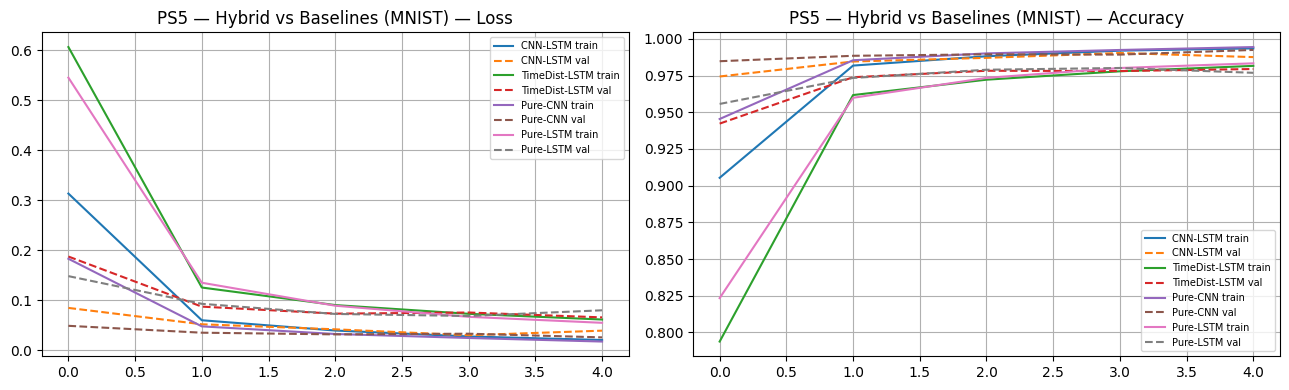


─── Hybrid on EMNIST-Letters ───
[CNN-LSTM-E] Ep 01/5 | Loss 0.5542/0.2497 | Acc 0.838/0.919
[CNN-LSTM-E] Ep 02/5 | Loss 0.2145/0.2107 | Acc 0.930/0.930
[CNN-LSTM-E] Ep 03/5 | Loss 0.1744/0.1913 | Acc 0.940/0.936
[CNN-LSTM-E] Ep 04/5 | Loss 0.1507/0.1815 | Acc 0.947/0.939
[CNN-LSTM-E] Ep 05/5 | Loss 0.1348/0.1785 | Acc 0.951/0.939
  → Time: 1762.2s | Params: 318,106
[TimeDist-LSTM-E] Ep 01/5 | Loss 0.9439/0.4300 | Acc 0.714/0.866
[TimeDist-LSTM-E] Ep 02/5 | Loss 0.3457/0.3241 | Acc 0.888/0.897
[TimeDist-LSTM-E] Ep 03/5 | Loss 0.2725/0.2865 | Acc 0.910/0.909
[TimeDist-LSTM-E] Ep 04/5 | Loss 0.2359/0.2518 | Acc 0.921/0.917
[TimeDist-LSTM-E] Ep 05/5 | Loss 0.2149/0.2306 | Acc 0.926/0.925
  → Time: 190.5s | Params: 137,082


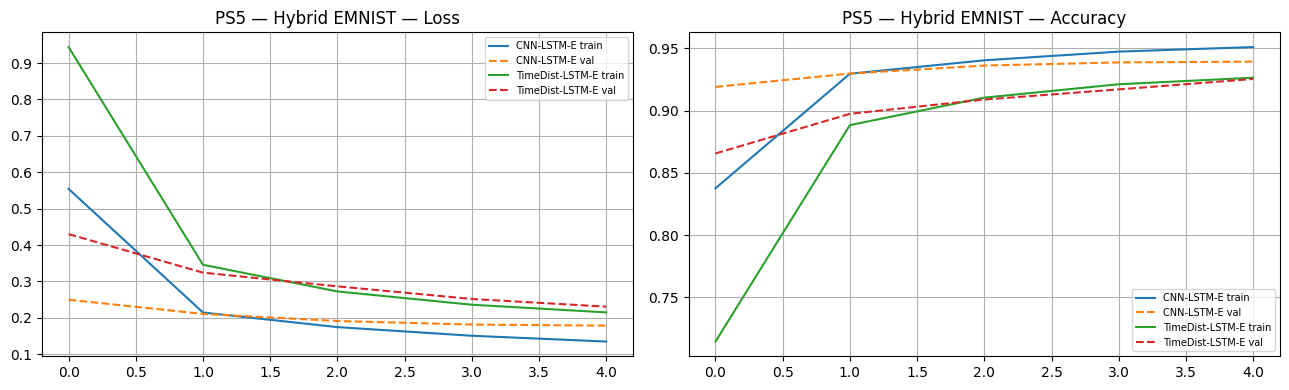

In [6]:
# ═══════════════════════════════════════════════════════════════
# PS5 — CNN + LSTM Hybrid
# ═══════════════════════════════════════════════════════════════

# ── Architecture A: CNN feature extractor → LSTM ──
class CNNLSTMModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # →14x14
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # →7x7
        )
        self.lstm = nn.LSTM(64 * 7, 128, batch_first=True)
        self.fc   = nn.Linear(128, num_classes)

    def forward(self, x):          # x: (B,28,28)
        x = x.unsqueeze(1)         # (B,1,28,28)
        feat = self.cnn(x)         # (B,64,7,7)
        B, C, H, W = feat.shape
        # treat H dimension as time steps, flatten C*W as features
        seq  = feat.permute(0, 2, 1, 3).reshape(B, H, C * W)  # (B,7,64*7)
        out, _ = self.lstm(seq)
        return self.fc(out[:, -1, :])

# ── Architecture B: Time-Distributed CNN → LSTM ──
class TimedistCNNLSTM(nn.Module):
    """Apply a small CNN to each row strip, feed row features into LSTM."""
    def __init__(self, num_classes):
        super().__init__()
        # each time step: 1 row of 28 pixels → treated as 1×28 image
        self.row_cnn = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(4),   # → (B,32,4)
        )
        self.lstm = nn.LSTM(32 * 4, 128, batch_first=True)
        self.fc   = nn.Linear(128, num_classes)

    def forward(self, x):          # x: (B,28,28)
        B, T, F = x.shape
        rows = x.reshape(B * T, 1, F)           # (B*T, 1, 28)
        feat = self.row_cnn(rows)               # (B*T, 32, 4)
        feat = feat.reshape(B, T, -1)           # (B, T, 128)
        out, _ = self.lstm(feat)
        return self.fc(out[:, -1, :])

# ── Pure CNN baseline ──
class PureCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256), nn.ReLU(),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.net(x.unsqueeze(1))   # add channel dim

# ── Run PS5 ───────────────────────────────────────────────────
print('─── CNN+LSTM Hybrid on MNIST ───')
hybrid_results = {}
for name, model in [
    ('CNN-LSTM',      CNNLSTMModel(NUM_CLASSES_MNIST)),
    ('TimeDist-LSTM', TimedistCNNLSTM(NUM_CLASSES_MNIST)),
    ('Pure-CNN',      PureCNN(NUM_CLASSES_MNIST)),
    ('Pure-LSTM',     LSTMModel(INPUT_SIZE, 128, 1, NUM_CLASSES_MNIST)),
]:
    model = model.to(DEVICE)
    h, _  = full_train(model, mnist_train_loader, mnist_test_loader,
                        epochs=EPOCHS_SHORT, label=name)
    hybrid_results[name] = h

plot_history(hybrid_results, 'PS5 — Hybrid vs Baselines (MNIST)')

print('\n─── Hybrid on EMNIST-Letters ───')
hybrid_emnist_results = {}
for name, model in [
    ('CNN-LSTM-E',      CNNLSTMModel(NUM_CLASSES_EMNIST)),
    ('TimeDist-LSTM-E', TimedistCNNLSTM(NUM_CLASSES_EMNIST)),
]:
    model = model.to(DEVICE)
    h, _  = full_train(model, emnist_train_loader, emnist_test_loader,
                        epochs=EPOCHS_SHORT, label=name)
    hybrid_emnist_results[name] = h

plot_history(hybrid_emnist_results, 'PS5 — Hybrid EMNIST')


─── PS6: Hyperparameter sweep (LSTM on MNIST) ───
H128-lr0.001-B128-dr0.2-adam-clipNone                        | ValAcc=0.983
H128-lr0.0001-B128-dr0.2-adam-clipNone                       | ValAcc=0.962
H256-lr0.001-B128-dr0.3-adam-clip1.0                         | ValAcc=0.983
H128-lr0.001-B64-dr0.3-adamw-clip1.0                         | ValAcc=0.988
H128-lr0.001-B128-dr0.2-rmsprop-clipNone                     | ValAcc=0.984
H64-lr0.01-B256-dr0.0-sgd-clip5.0                            | ValAcc=0.114


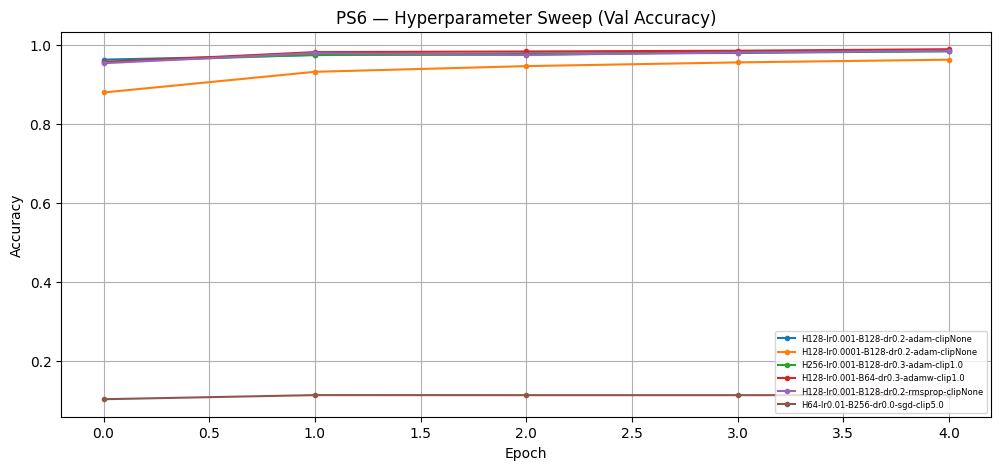

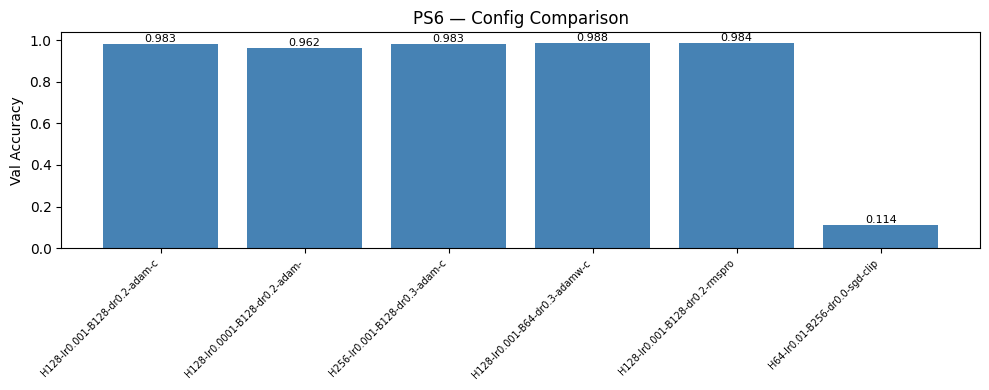

In [7]:
# ═══════════════════════════════════════════════════════════════
# PS6 — Hyperparameter Tuning & Regularization
# ═══════════════════════════════════════════════════════════════

from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau

def hp_experiment(hidden, lr, batch, dropout, optimizer_name,
                  clip, dataset='mnist', epochs=EPOCHS_SHORT):
    train_loader = mnist_train_loader if dataset == 'mnist' else emnist_train_loader
    test_loader  = mnist_test_loader  if dataset == 'mnist' else emnist_test_loader
    num_classes  = NUM_CLASSES_MNIST  if dataset == 'mnist' else NUM_CLASSES_EMNIST

    # rebuild loader with custom batch size
    ds_train = mnist_train if dataset == 'mnist' else emnist_train
    ds_test  = mnist_test  if dataset == 'mnist' else emnist_test
    tl = DataLoader(ds_train, batch_size=batch, shuffle=True)
    vl = DataLoader(ds_test,  batch_size=batch, shuffle=False)

    model = LSTMModel(INPUT_SIZE, hidden, 2, num_classes, dropout=dropout).to(DEVICE)
    criterion = nn.CrossEntropyLoss()

    opts = {'adam': optim.Adam, 'sgd': optim.SGD,
            'rmsprop': optim.RMSprop, 'adamw': optim.AdamW}
    optimizer = opts[optimizer_name](model.parameters(), lr=lr,
                                      weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for ep in range(1, epochs + 1):
        trl, tra = train_one_epoch(model, tl, optimizer, criterion, clip=clip)
        vl_loss, va = evaluate(model, vl, criterion)
        scheduler.step(vl_loss)
        history['train_loss'].append(trl); history['train_acc'].append(tra)
        history['val_loss'].append(vl_loss); history['val_acc'].append(va)

    label = f'H{hidden}-lr{lr}-B{batch}-dr{dropout}-{optimizer_name}-clip{clip}'
    print(f'{label:60s} | ValAcc={va:.3f}')
    return label, history

# ── Grid sweep (representative subset) ──
print('─── PS6: Hyperparameter sweep (LSTM on MNIST) ───')
hp_results = {}

experiments = [
    # (hidden, lr,    batch, dropout, optim,    clip)
    (128, 1e-3, 128, 0.2, 'adam',    None),
    (128, 1e-4, 128, 0.2, 'adam',    None),
    (256, 1e-3, 128, 0.3, 'adam',    1.0),
    (128, 1e-3, 64,  0.3, 'adamw',   1.0),
    (128, 1e-3, 128, 0.2, 'rmsprop', None),
    (64,  1e-2, 256, 0.0, 'sgd',     5.0),
]

for cfg in experiments:
    label, h = hp_experiment(*cfg)
    hp_results[label] = h

# plot val acc comparison
plt.figure(figsize=(12, 5))
for label, h in hp_results.items():
    plt.plot(h['val_acc'], label=label[:40], marker='o', markersize=3)
plt.title('PS6 — Hyperparameter Sweep (Val Accuracy)')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(fontsize=6, loc='lower right'); plt.grid(True); plt.show()

# Best config bar chart
plt.figure(figsize=(10, 4))
names  = [l[:30] for l in hp_results]
accs   = [h['val_acc'][-1] for h in hp_results.values()]
bars   = plt.bar(names, accs, color='steelblue')
plt.bar_label(bars, fmt='%.3f', fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.ylabel('Val Accuracy'); plt.title('PS6 — Config Comparison')
plt.tight_layout(); plt.show()



[VanillaRNN] Ep 01/15 | Loss 0.8772/0.4900 | Acc 0.701/0.847
[VanillaRNN] Ep 02/15 | Loss 0.4208/0.3098 | Acc 0.873/0.909
[VanillaRNN] Ep 03/15 | Loss 0.3033/0.2812 | Acc 0.915/0.918
[VanillaRNN] Ep 04/15 | Loss 0.2370/0.2493 | Acc 0.933/0.929
[VanillaRNN] Ep 05/15 | Loss 0.1999/0.1808 | Acc 0.944/0.946
[VanillaRNN] Ep 06/15 | Loss 0.1714/0.1656 | Acc 0.952/0.956
[VanillaRNN] Ep 07/15 | Loss 0.1544/0.2021 | Acc 0.956/0.947
[VanillaRNN] Ep 08/15 | Loss 0.1372/0.1556 | Acc 0.961/0.955
[VanillaRNN] Ep 09/15 | Loss 0.1255/0.1308 | Acc 0.965/0.964
[VanillaRNN] Ep 10/15 | Loss 0.1237/0.1388 | Acc 0.965/0.961
[VanillaRNN] Ep 11/15 | Loss 0.1158/0.1197 | Acc 0.967/0.965
[VanillaRNN] Ep 12/15 | Loss 0.1045/0.1078 | Acc 0.970/0.969
[VanillaRNN] Ep 13/15 | Loss 0.1031/0.1539 | Acc 0.970/0.955
[VanillaRNN] Ep 14/15 | Loss 0.1037/0.1232 | Acc 0.970/0.964
[VanillaRNN] Ep 15/15 | Loss 0.0950/0.1291 | Acc 0.973/0.963
  → Time: 141.2s | Params: 21,514
[LSTM] Ep 01/15 | Loss 0.4693/0.1339 | Acc 0.847/0.

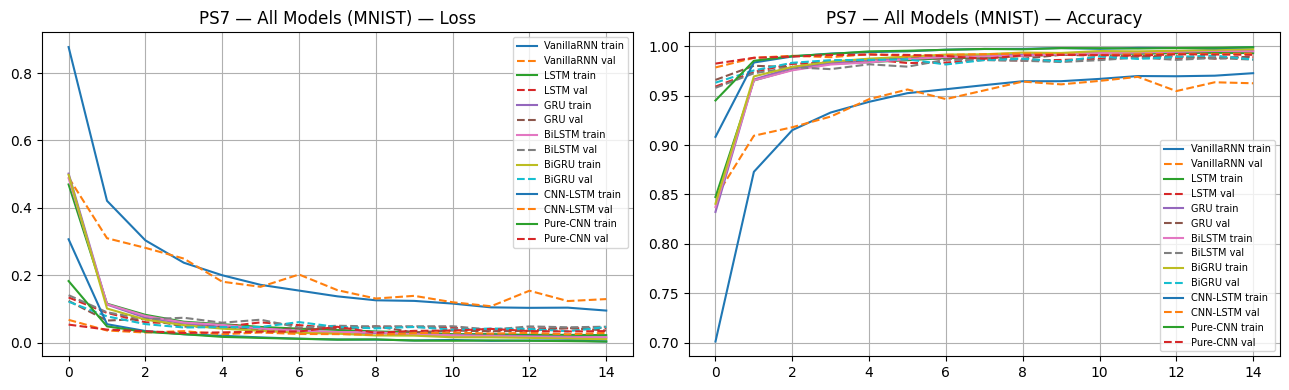

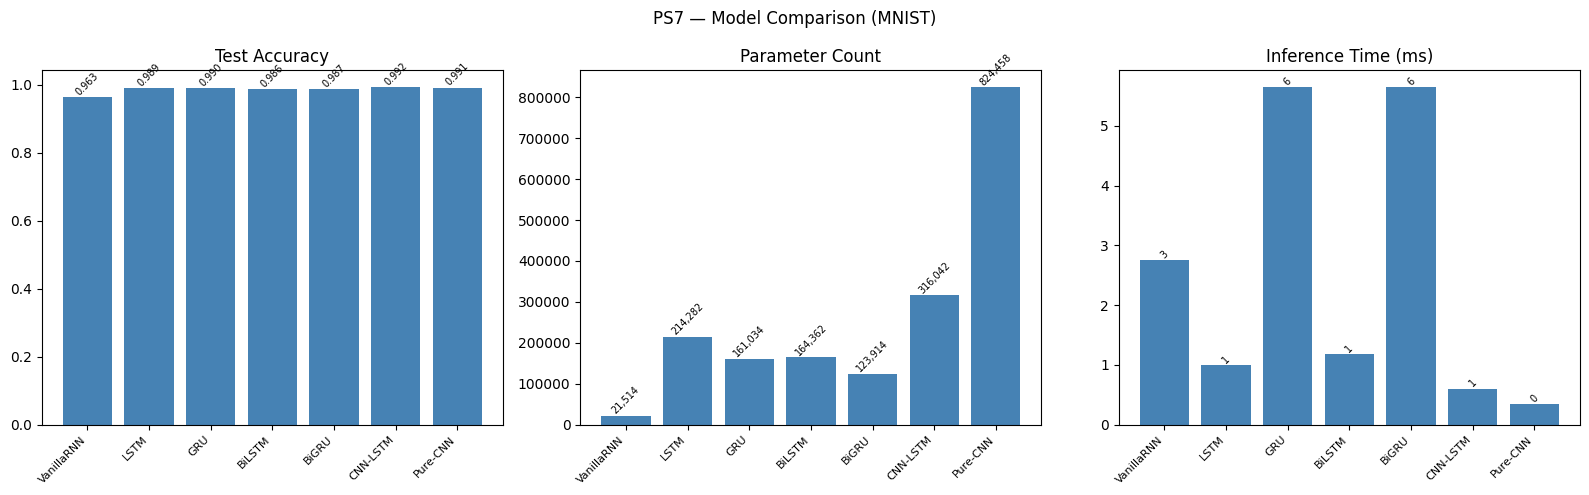


Best model: CNN-LSTM | Acc=0.992


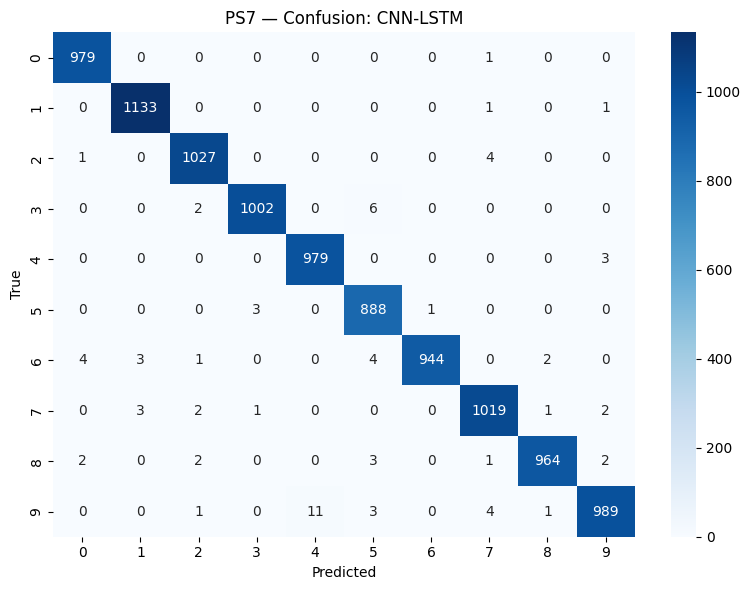

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.98      1.00      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



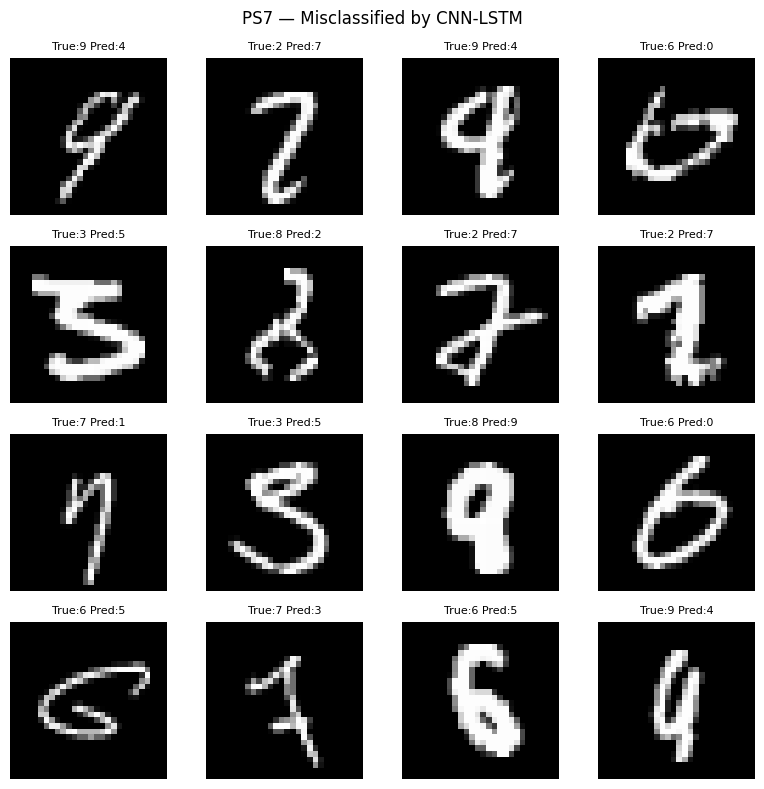


─── t-SNE  ───


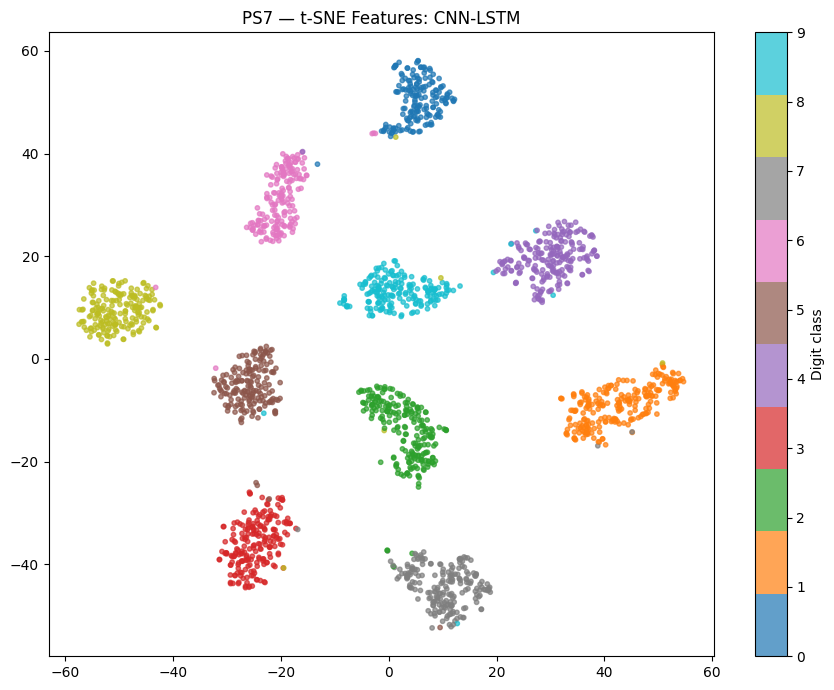


Model            ValAcc       Params   Train(s)   Infer(ms)
────────────────────────────────────────────────────────────
CNN-LSTM          0.992      316,042      185.4        0.60
Pure-CNN          0.991      824,458      155.6        0.34
GRU               0.990      161,034      280.5        5.65
LSTM              0.989      214,282      170.4        0.99
BiGRU             0.987      123,914      274.4        5.65
BiLSTM            0.986      164,362      167.4        1.18
VanillaRNN        0.963       21,514      141.2        2.75


In [8]:
# ═══════════════════════════════════════════════════════════════
# PS7 — Comprehensive Comparative Analysis
# ═══════════════════════════════════════════════════════════════
from sklearn.manifold import TSNE

# ── Train all final models (MNIST) ────────────────────────────
FINAL_EPOCHS = EPOCHS_FULL   # set to 15 for thorough results

final_models = {
    'VanillaRNN': VanillaRNN(INPUT_SIZE, 128, 1, NUM_CLASSES_MNIST),
    'LSTM':       LSTMModel(INPUT_SIZE, 128, 2, NUM_CLASSES_MNIST, dropout=0.3),
    'GRU':        GRUModel(INPUT_SIZE, 128, 2, NUM_CLASSES_MNIST, dropout=0.3),
    'BiLSTM':     BiRNN(INPUT_SIZE, 128, NUM_CLASSES_MNIST, rnn_type='lstm', merge='concat'),
    'BiGRU':      BiRNN(INPUT_SIZE, 128, NUM_CLASSES_MNIST, rnn_type='gru',  merge='concat'),
    'CNN-LSTM':   CNNLSTMModel(NUM_CLASSES_MNIST),
    'Pure-CNN':   PureCNN(NUM_CLASSES_MNIST),
}

all_histories = {}
all_summary   = {}

for name, model in final_models.items():
    model = model.to(DEVICE)
    h, t  = full_train(model, mnist_train_loader, mnist_test_loader,
                        epochs=FINAL_EPOCHS, label=name)
    all_histories[name] = h
    all_summary[name]   = {
        'val_acc':    h['val_acc'][-1],
        'params':     count_params(model),
        'train_sec':  t,
        'infer_ms':   measure_inference_time(model, mnist_test_loader),
    }
    final_models[name] = model   # store trained model back

# ── 1. Training curves ─────────────────────────────────────────
plot_history(all_histories, 'PS7 — All Models (MNIST)')

# ── 2. Summary bar charts ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
names = list(all_summary.keys())
for ax, key, title in zip(axes,
                           ['val_acc', 'params', 'infer_ms'],
                           ['Test Accuracy', 'Parameter Count', 'Inference Time (ms)']):
    vals = [all_summary[n][key] for n in names]
    bars = ax.bar(names, vals, color='steelblue')
    ax.bar_label(bars,
                 labels=[f'{v:.3f}' if key=='val_acc' else f'{v:,.0f}' for v in vals],
                 fontsize=7, rotation=45)
    ax.set_title(title); ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
plt.suptitle('PS7 — Model Comparison (MNIST)'); plt.tight_layout(); plt.show()

# ── 3. Confusion matrix — best model ──────────────────────────
best_name  = max(all_summary, key=lambda n: all_summary[n]['val_acc'])
best_model = final_models[best_name]
print(f'\nBest model: {best_name} | Acc={all_summary[best_name]["val_acc"]:.3f}')
plot_confusion(best_model, mnist_test_loader,
               classes=list(range(10)), title=f'PS7 — Confusion: {best_name}')

# ── 4. Misclassified samples ───────────────────────────────────
best_model.eval()
misclassified_imgs, mis_true, mis_pred = [], [], []
with torch.no_grad():
    for X, y in mnist_test_loader:
        out   = best_model(X.squeeze(1).to(DEVICE))
        preds = out.argmax(1).cpu()
        mask  = preds != y
        misclassified_imgs.extend(X[mask].squeeze(1).numpy())
        mis_true.extend(y[mask].numpy())
        mis_pred.extend(preds[mask].numpy())
        if len(misclassified_imgs) >= 16: break

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for ax, img, t, p in zip(axes.flatten(),
                           misclassified_imgs, mis_true, mis_pred):
    ax.imshow(img, cmap='gray')
    ax.set_title(f'True:{t} Pred:{p}', fontsize=8)
    ax.axis('off')
plt.suptitle(f'PS7 — Misclassified by {best_name}')
plt.tight_layout(); plt.show()

# ── 5. t-SNE feature visualization ────────────────────────────
print('\n─── t-SNE  ───')

def extract_features(model, loader, max_samples=2000):
    """Extract penultimate-layer features via forward hook."""
    features, labels = [], []
    handle = None

    # register hook on fc layer's input
    def hook_fn(module, inp, out):
        features.append(inp[0].detach().cpu())

    # find the final Linear layer
    for layer in reversed(list(model.modules())):
        if isinstance(layer, nn.Linear):
            handle = layer.register_forward_hook(hook_fn)
            break

    model.eval()
    with torch.no_grad():
        for X, y in loader:
            model(X.squeeze(1).to(DEVICE))
            labels.extend(y.numpy())
            if sum(f.shape[0] for f in features) >= max_samples:
                break
    if handle: handle.remove()

    feats = torch.cat(features, dim=0)[:max_samples].numpy()
    lbls  = np.array(labels)[:max_samples]
    return feats, lbls

feats, lbls = extract_features(best_model, mnist_test_loader)
tsne_emb    = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(feats)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(tsne_emb[:, 0], tsne_emb[:, 1],
                       c=lbls, cmap='tab10', s=10, alpha=0.7)
plt.colorbar(scatter, ticks=range(10), label='Digit class')
plt.title(f'PS7 — t-SNE Features: {best_name}')
plt.tight_layout(); plt.show()

# ── 6. Final summary table ─────────────────────────────────────
print(f'\n{"Model":<14} {"ValAcc":>8} {"Params":>12} {"Train(s)":>10} {"Infer(ms)":>11}')
print('─' * 60)
for name, s in sorted(all_summary.items(), key=lambda x: -x[1]['val_acc']):
    print(f'{name:<14} {s["val_acc"]:>8.3f} {s["params"]:>12,} '
          f'{s["train_sec"]:>10.1f} {s["infer_ms"]:>11.2f}')

